# AI Resume Screening System using NLP & Machine Learning

## Project Overview

Recruiters receive thousands of resumes for different job roles, making manual screening time-consuming and inefficient.

This project builds an AI-powered Resume Screening System that automatically classifies resumes into job categories using:

- Natural Language Processing (NLP)
- TF-IDF Vectorization
- Machine Learning Algorithms
- Hyperparameter Tuning

The system can help automate the initial hiring process and improve recruitment efficiency.

In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from wordcloud import WordCloud

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [43]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [44]:
df = pd.read_csv(
    '/kaggle/input/datasets/snehaanbhawal/resume-dataset/Resume/Resume.csv'
)

In [45]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [46]:
print('Dataset Shape:', df.shape)

print(df.columns)

print(df.info())

Dataset Shape: (2484, 4)
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB
None


In [47]:
# Duplicate Values

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [48]:
df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

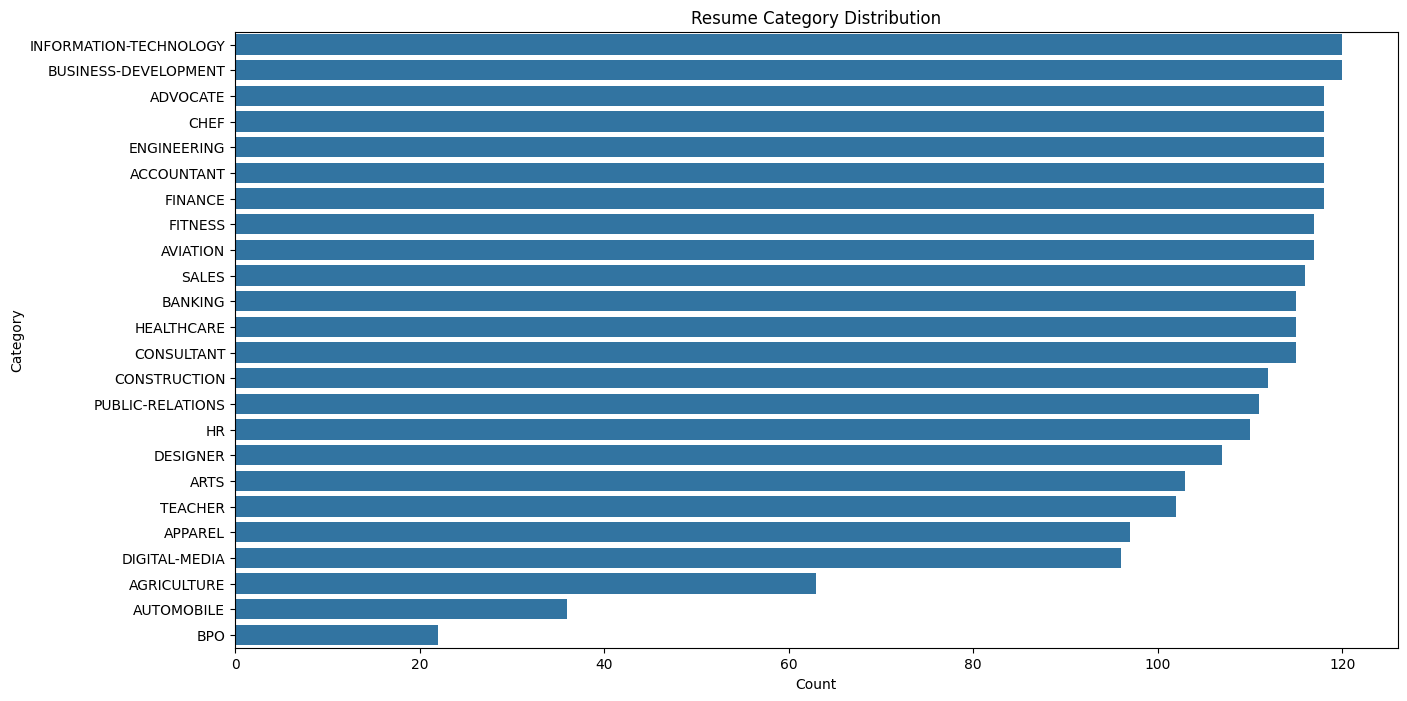

In [49]:
plt.figure(figsize=(15,8))

sns.countplot(
    y=df['Category'],
    order=df['Category'].value_counts().index
)

plt.title('Resume Category Distribution')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

## Word Cloud Visualization

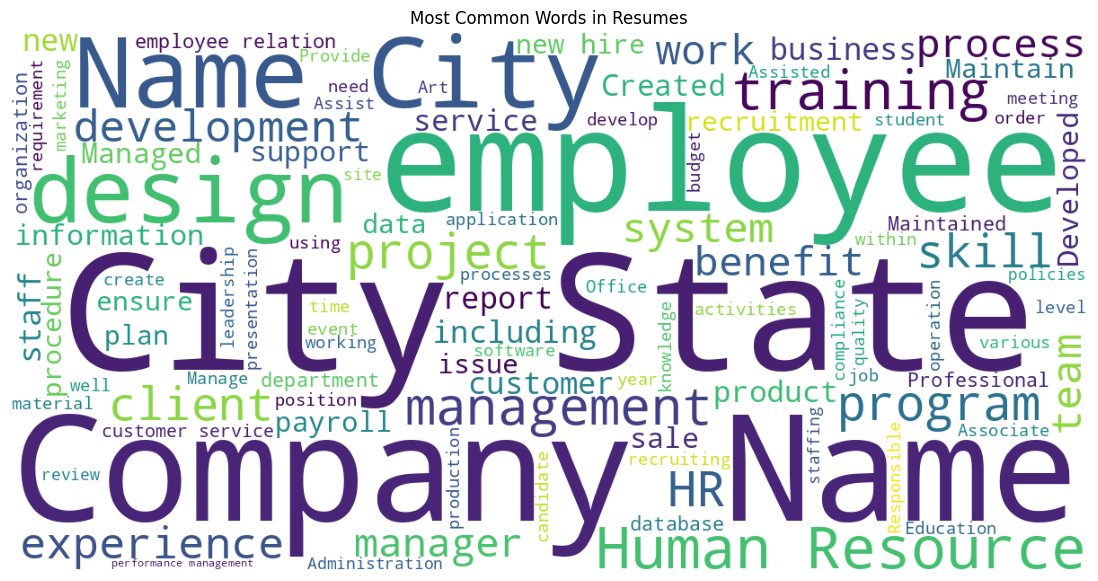

In [50]:
text = " ".join(df['Resume_str'].head(200))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('Most Common Words in Resumes')

plt.show()

## Text Preprocessing

In [51]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_resume(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+', ' ', text)

    # Remove mentions
    text = re.sub(r'@\w+', ' ', text)

    # Remove hashtags
    text = re.sub(r'#\w+', ' ', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(cleaned_words)

In [52]:
df['Cleaned_Resume'] = df['Resume_str'].apply(clean_resume)

df[['Resume_str', 'Cleaned_Resume']].head()

,Resume_str,Cleaned_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administratormarketing associate hr adminis...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist u hr operation summary versatile...
2,HR DIRECTOR Summary Over 2...,hr director summary year experience recruiting...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,hr manager skill highlight hr skill hr departm...


## Encoding Target Labels

In [53]:
encoder = LabelEncoder()

df['Category_Encoded'] = encoder.fit_transform(df['Category'])

# Display categories

print(encoder.classes_)

['ACCOUNTANT' 'ADVOCATE' 'AGRICULTURE' 'APPAREL' 'ARTS' 'AUTOMOBILE'
 'AVIATION' 'BANKING' 'BPO' 'BUSINESS-DEVELOPMENT' 'CHEF' 'CONSTRUCTION'
 'CONSULTANT' 'DESIGNER' 'DIGITAL-MEDIA' 'ENGINEERING' 'FINANCE' 'FITNESS'
 'HEALTHCARE' 'HR' 'INFORMATION-TECHNOLOGY' 'PUBLIC-RELATIONS' 'SALES'
 'TEACHER']


In [54]:
X = df['Cleaned_Resume']
y = df['Category_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training Size:', X_train.shape)
print('Testing Size:', X_test.shape)

Training Size: (1987,)
Testing Size: (497,)


## TF-IDF Vectorization

Machine Learning models cannot understand raw text directly.
TF-IDF converts text into numerical vectors based on word importance.

In [55]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(1987, 5000)


## Naive Bayes Model

In [56]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_pred)

print('Naive Bayes Accuracy:', nb_accuracy)

Naive Bayes Accuracy: 0.5573440643863179


## Logistic Regression Model

In [70]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_pred)

print('Logistic Regression Accuracy:', lr_accuracy)

Logistic Regression Accuracy: 0.6680080482897385


## Random Forest Model

In [71]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)

rf_accuracy = accuracy_score(y_test, rf_pred)

print('Random Forest Accuracy:', rf_accuracy)

Random Forest Accuracy: 0.7565392354124748


## XGBoost Model

In [73]:
xgb_model = XGBClassifier(
    n_estimators=20,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    tree_method='hist'
)

xgb_model.fit(X_train_tfidf, y_train)

xgb_pred = xgb_model.predict(X_test_tfidf)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.778672032193159


## Model Comparison

In [74]:
models = ['Naive Bayes', 'Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [
    nb_accuracy,
    lr_accuracy,
    rf_accuracy,
    xgb_accuracy
]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

comparison_df

,Model,Accuracy
0,Naive Bayes,0.557344
1,Logistic Regression,0.668008
2,Random Forest,0.756539
3,XGBoost,0.778672


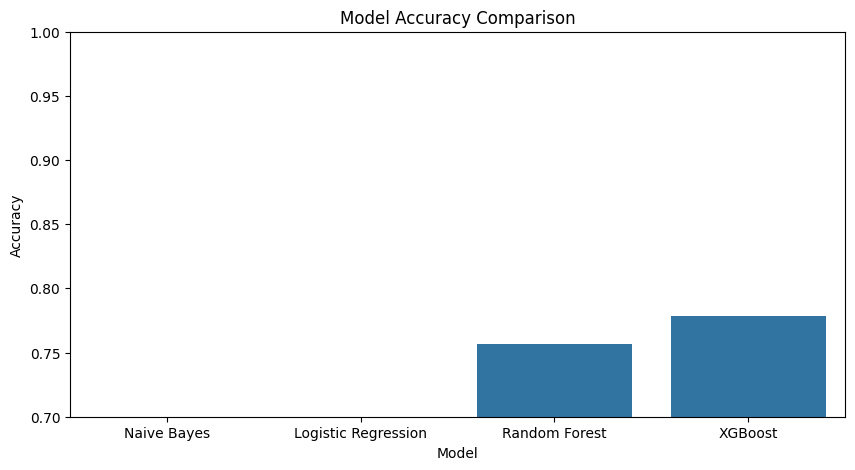

In [75]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title('Model Accuracy Comparison')
plt.ylim(0.7,1.0)
plt.show()

## Classification Report

In [76]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.67      0.83      0.74        24
           1       0.31      0.46      0.37        24
           2       1.00      0.46      0.63        13
           3       0.60      0.16      0.25        19
           4       0.57      0.38      0.46        21
           5       0.00      0.00      0.00         7
           6       0.85      0.71      0.77        24
           7       0.85      0.74      0.79        23
           8       0.00      0.00      0.00         4
           9       0.54      0.92      0.68        24
          10       0.86      0.75      0.80        24
          11       0.85      0.77      0.81        22
          12       0.55      0.26      0.35        23
          13       0.81      0.81      0.81        21
          14       0.77      0.53      0.62        19
          15       0.73      0.79      0.76        24
          16       0.89      0.67      0.76        24
          17       0.84    

## Confusion Matrix

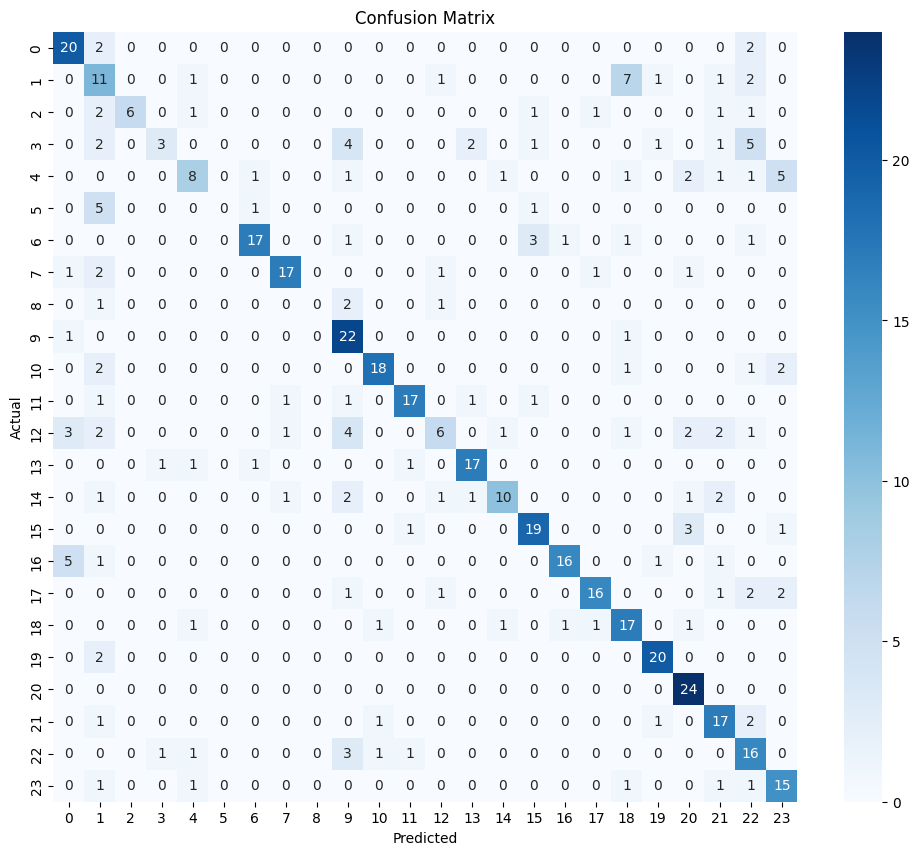

In [77]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Hyperparameter Tuning

Hyperparameter tuning improves model performance by searching for the best parameter combinations.

In [78]:
params = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_tfidf, y_train)

print('Best Parameters:', grid.best_params_)
print('Best Score:', grid.best_score_)

Best Parameters: {'C': 10, 'solver': 'liblinear'}
Best Score: 0.6768905718612489


In [79]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test_tfidf)

print('Final Accuracy:', accuracy_score(y_test, best_pred))

Final Accuracy: 0.7062374245472837


## Resume Prediction System

In [80]:
sample_resume = """
Experienced Data Scientist skilled in Python,
Machine Learning, Deep Learning, SQL,
Power BI and Data Analysis.
"""

# Clean text
cleaned_resume = clean_resume(sample_resume)

# Vectorize
vectorized_resume = vectorizer.transform([cleaned_resume])

# Predict
prediction = best_model.predict(vectorized_resume)

# Decode prediction
predicted_category = encoder.inverse_transform(prediction)

print('Predicted Category:', predicted_category[0])

Predicted Category: ENGINEERING


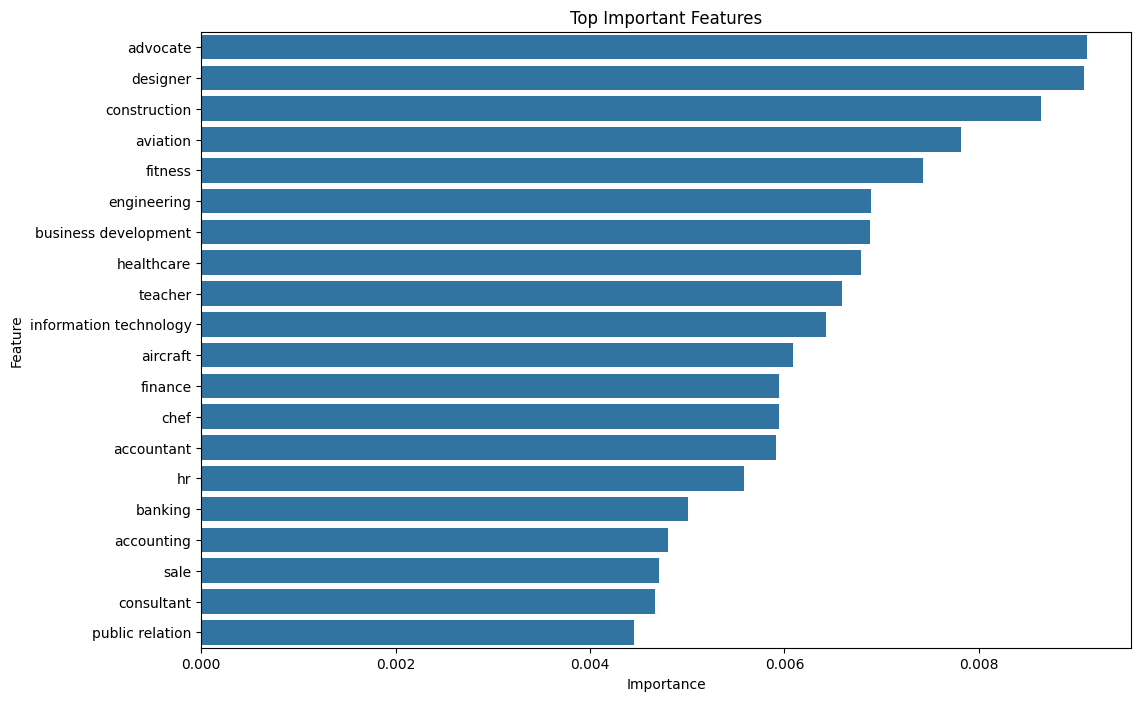

In [81]:
feature_names = vectorizer.get_feature_names_out()

importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title('Top Important Features')
plt.show()

## Saving Model

In [82]:
import pickle

# Save vectorizer
pickle.dump(vectorizer, open('tfidf_vectorizer.pkl', 'wb'))

# Save model
pickle.dump(best_model, open('resume_classifier.pkl', 'wb'))

# Save encoder
pickle.dump(encoder, open('label_encoder.pkl', 'wb'))

# 📌 Conclusion

In this project, we successfully developed an AI-powered Resume Screening System using NLP and Machine Learning.

Key achievements:
- Resume preprocessing using NLP
- TF-IDF feature extraction
- Multiple ML model training
- Hyperparameter tuning
- Automated resume category prediction

The project demonstrates how AI can assist recruiters in automating the hiring process efficiently.